In [1]:
import pandas as pd
import os
import glob
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
import matplotlib.pyplot as plt
from IPython.display import HTML, display, Markdown
from copy import copy
import seaborn as sns
import numpy as np
import datetime as dt
from dateutil.relativedelta import relativedelta

from utils.conn_data import load_pickle

In [2]:
dataset_names = {
    'SPY': 'etfs_macro_large',
    'ldEXME': 'monetary-policy-processed'
}

outputs_path = os.path.join(os.path.dirname(os.getcwd()), "src", "data", "outputs")
results_path = os.path.join(os.path.dirname(os.getcwd()), "src", "data", "outputs", "results")

fs_methods_tags = {
    "seqICP_nocluster": "SeqICP",
    "pcmci_nocluster": "PCMCI",
    "pairwise-granger_nocluster": "Pairwise Granger",
    "multivariate-granger_nocluster": "Multivariate Granger",
    "dynotears_nocluster": "Dynotears",
    "var-lingam_nocluster": "VAR-LiNGAM",
    "sfscv-forward-lin_nocluster": "SFSCV F Lin",
    "sfscv-backward-lin_nocluster": "SFSCV B Lin",
    "sfscv-forward-svm_nocluster": "SFSCV F SVM",
    "sfscv-backward-svm_nocluster": "SFSCV B SVM",
    "sfscv-forward-rf_nocluster": "SFSCV F RF",
    "sfscv-backward-rf_nocluster": "SFSCV B RF",
    "sfstscv-forward-lin_nocluster": "SFSTSCV F Lin",
    "sfstscv-backward-lin_nocluster": "SFSTSCV B Lin",
    "sfstscv-forward-svm_nocluster": "SFSTSCV F SVM",
    "sfstscv-backward-svm_nocluster": "SFSTSCV B SVM",
    "sfstscv-forward-rf_nocluster": "SFSTSCV F RF",
    "sfstscv-backward-rf_nocluster": "SFSTSCV B RF",

}

all_fs_methods = {
    'SPY': [
        "sfscv-forward-lin_nocluster",
        "sfscv-backward-lin_nocluster",
        "sfscv-forward-svm_nocluster",
        "sfscv-backward-svm_nocluster",
        "sfscv-forward-rf_nocluster",
        "sfscv-backward-rf_nocluster",
        "sfstscv-forward-lin_nocluster",
        "sfstscv-backward-lin_nocluster",
        "sfstscv-forward-svm_nocluster",
        "sfstscv-backward-svm_nocluster",
        "sfstscv-forward-rf_nocluster",
        "sfstscv-backward-rf_nocluster"

        # "sfscv-backward-svm_nocluster",
        "dynotears_nocluster", 
        "pairwise-granger_nocluster",
        "multivariate-granger_nocluster",
        # "seqICP_nocluster",
        "pcmci_nocluster",
        "var-lingam_nocluster",
    ],

    'ldEXME': [
        "seqICP_nocluster",
        "pcmci_nocluster",
        "dynotears_nocluster", 
        "pairwise-granger_nocluster",
        "multivariate-granger_nocluster",
        "var-lingam_nocluster",
        "sfscv-forward-lin_nocluster",
        "sfscv-backward-lin_nocluster",
        "sfscv-forward-svm_nocluster",
        "sfscv-backward-svm_nocluster",
        "sfscv-forward-rf_nocluster",
        "sfscv-backward-rf_nocluster",
        "sfstscv-forward-lin_nocluster",
        "sfstscv-backward-lin_nocluster",
        "sfstscv-forward-svm_nocluster",
        "sfstscv-backward-svm_nocluster",
        "sfstscv-forward-rf_nocluster",
        "sfstscv-backward-rf_nocluster"
    ]

}

etfs_large = [
    "SPY"
    # "ldEXME"
]

# event_dates = [
#     ("GFC", ("2007-07-01", "2008-11-01")),
#     ("Dow Jones Flash Crash", ("2010-03-01", "2010-07-01")),
#     ("Tsunami Fukushima", ("2011-01-01", "2011-05-01")),
#     ("Black Monday 2011", ("2011-06-01", "2011-10-01")),
#     ("Chinese Black Monday", ("2015-06-01", "2015-10-01")),
#     ("Dow Jones Plunge 2018", ("2018-01-01", "2018-05-01")),
#     ("COVID-19", ("2020-01-01", "2020-05-01"))
# ]

# event_dates = [
#     ("GFC", ("2007-07-01", "2008-11-01")),
#     ("Dow Jones Flash Crash", ("2010-03-01", "2010-07-01")),
#     ("Tsunami Fukushima", ("2011-01-01", "2011-05-01")),
#     ("Black Monday 2011", ("2011-06-01", "2011-10-01")),
#     ("Chinese Black Monday", ("2015-06-01", "2015-10-01")),
#     ("Dow Jones Plunge 2018", ("2018-01-01", "2018-05-01")),
#     ("COVID-19", ("2020-01-01", "2020-05-01"))
# ]

# threshold = 50

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def r2_oos(y_true, y_pred):
    """Modified R2-OOS using random walk benchmark (lagged value)."""
    ss_res = np.sum((y_true.values[1:] - y_pred.values[1:]) ** 2)
    ss_tot = np.sum((y_true.values[1:] - y_true.values[:-1]) ** 2)
    return 1 - ss_res / ss_tot

all_pred_measures = []
all_rolling_metrics = []

window = 12

for etf in etfs_large:
    dataset_name = dataset_names[etf]
    fs_methods = all_fs_methods[etf]
    
    # Collect predictions from all methods
    all_preds = {}
    true_values = None
    
    for i, fs in enumerate(fs_methods):
        files = glob.glob(os.path.join(outputs_path, fs, dataset_name, f"{etf}*.pickle"))

        if len(files) != 1:
            # raise ValueError(f"Found {len(files)} files for {etf} and {fs}.")
            print(f"Files found for {etf} and {fs}: {files}")
            continue

        for f in files:
            dfPred = load_pickle(f)["predictions"].loc["2006-01-01":]
            
            tag = fs_methods_tags[fs]
            all_preds[tag] = dfPred["prediction"]
            
            if true_values is None:
                true_values = dfPred["true"]
    
    # Build predictions dataframe
    dfPredAll = pd.DataFrame(all_preds, index=true_values.index)
    dfPredAll["true"] = true_values
    
    # Compute rolling metrics for each method
    for tag in all_preds.keys():
        rolling_df = pd.DataFrame(index=dfPredAll.index)
        rolling_df["diff"] = dfPredAll["true"] - dfPredAll[tag]
        rolling_df["rolling_mse"] = (rolling_df["diff"] ** 2).rolling(window).mean()
        rolling_df["rolling_rmse"] = np.sqrt(rolling_df["rolling_mse"])
        rolling_df["rolling_mae"] = rolling_df["diff"].abs().rolling(window).mean()
        
        # Melt for storage
        rolling_df["fs"] = tag
        rolling_df["etf"] = etf
        melt_rolling_df = rolling_df[["rolling_mse", "rolling_rmse", "rolling_mae", "fs", "etf"]].reset_index().melt(
            id_vars=["date", "fs", "etf"],
            var_name="variable",
            value_name="value"
        )
        all_rolling_metrics.append(melt_rolling_df)
    
    # Compute volatility based regime classification
    volatility = true_values.rolling(6).std() * np.sqrt(12)
    threshold = volatility.mean()
    
    crisis_idx = volatility[volatility >= threshold].dropna().index
    normal_idx = volatility[volatility < threshold].dropna().index
    
    # Align indices
    crisis_idx = crisis_idx.intersection(dfPredAll.index)
    normal_idx = normal_idx.intersection(dfPredAll.index)
    
    # Compute metrics for each method
    measures = []
    for tag in all_preds.keys():
        pred = dfPredAll[tag]
        true = dfPredAll["true"]
        
        # Full sample
        rmse_full = np.sqrt(mean_squared_error(true, pred))
        r2_full = r2_oos(true, pred)
        
        # Normal period
        true_normal = true.loc[normal_idx]
        pred_normal = pred.loc[normal_idx]
        rmse_normal = np.sqrt(mean_squared_error(true_normal, pred_normal))
        r2_normal = r2_oos(true_normal, pred_normal)
        
        # Crisis period
        true_crisis = true.loc[crisis_idx]
        pred_crisis = pred.loc[crisis_idx]
        rmse_crisis = np.sqrt(mean_squared_error(true_crisis, pred_crisis))
        r2_crisis = r2_oos(true_crisis, pred_crisis)
        
        measures.append({
            "index": tag,
            "etf": etf,
            "RMSE": rmse_full,
            "RMSE_normal": rmse_normal,
            "RMSE_crisis": rmse_crisis,
            "RMSE_gap": rmse_crisis - rmse_normal,
            "R2_OOS": r2_full,
            "R2_OOS_normal": r2_normal,
            "R2_OOS_crisis": r2_crisis,
            "R2_OOS_gap": r2_crisis - r2_normal,
        })
    
    measures_df = pd.DataFrame(measures)
    all_pred_measures.append(measures_df)

all_pred_measures_df = pd.concat(all_pred_measures, ignore_index=True)
all_rolling_metrics_df = pd.concat(all_rolling_metrics, ignore_index=True)

# Define display order matching the table
pbfs_order = [
    "SFSCV B Lin", "SFSCV B RF", "SFSCV B SVM",
    "SFSCV F Lin",
    "SFSCV F RF", "SFSCV F SVM",
    "SFSTSCV B Lin", "SFSTSCV B RF", "SFSTSCV B SVM",
    "SFSTSCV F Lin", "SFSTSCV F RF", "SFSTSCV F SVM",
]

ibfs_order = [
    "SeqICP", "VAR-LiNGAM",
    "Dynotears", "Multivariate Granger",
    "PCMCI", "Pairwise Granger",
]

display_order = pbfs_order + ibfs_order

# Reorder and display
pivot = all_pred_measures_df.set_index("index")[[
    "R2_OOS_normal", "R2_OOS_crisis", "R2_OOS_gap",
    "RMSE_normal", "RMSE_crisis", "RMSE_gap"
]].round(4)

pivot = pivot.reindex(display_order)

pivot.dropna(how='all')

Files found for SPY and sfscv-backward-lin_nocluster: []
Files found for SPY and sfscv-forward-svm_nocluster: []
Files found for SPY and sfscv-forward-rf_nocluster: []
Files found for SPY and sfscv-backward-rf_nocluster: []
Files found for SPY and sfstscv-forward-lin_nocluster: []
Files found for SPY and sfstscv-backward-lin_nocluster: []
Files found for SPY and sfstscv-forward-svm_nocluster: []
Files found for SPY and sfstscv-backward-svm_nocluster: []
Files found for SPY and sfstscv-forward-rf_nocluster: []
Files found for SPY and sfstscv-backward-rf_noclusterdynotears_nocluster: []


,R2_OOS_normal,R2_OOS_crisis,R2_OOS_gap,RMSE_normal,RMSE_crisis,RMSE_gap
index,,,,,,
SFSCV B SVM,-13.5211,-0.7565,12.7646,0.1578,0.1186,-0.0392
SFSCV F Lin,0.2299,-1.0050,-1.2349,0.0374,0.1263,0.0889
VAR-LiNGAM,0.5113,0.5226,0.0113,0.0289,0.0624,0.0335
Multivariate Granger,0.4901,0.2874,-0.2027,0.0297,0.0760,0.0464
PCMCI,0.5141,0.4567,-0.0574,0.0288,0.0668,0.0380
Pairwise Granger,0.4579,0.0297,-0.4282,0.0306,0.0885,0.0579


In [26]:
print(pivot.dropna(how='all'))

                      R2_OOS_normal  R2_OOS_crisis  R2_OOS_gap  RMSE_normal  \
index                                                                         
SFSCV B SVM                -13.5211        -0.7565     12.7646       0.1578   
VAR-LiNGAM                   0.5113         0.5226      0.0113       0.0289   
Dynotears                    0.5083         0.4941     -0.0142       0.0290   
Multivariate Granger         0.4901         0.2874     -0.2027       0.0297   
PCMCI                        0.5141         0.4567     -0.0574       0.0288   
Pairwise Granger             0.4579         0.0297     -0.4282       0.0306   

                      RMSE_crisis  RMSE_gap  
index                                        
SFSCV B SVM                0.1186   -0.0392  
VAR-LiNGAM                 0.0624    0.0335  
Dynotears                  0.0644    0.0354  
Multivariate Granger       0.0760    0.0464  
PCMCI                      0.0668    0.0380  
Pairwise Granger           0.0885    0.0579  

## Debugging

In [5]:
# fs = "seqICP_nocluster"

# # list results files with glob
# results_files = glob.glob(os.path.join(outputs_path, fs, "monetary-policy-processed", "*.pickle"))

# file = next(iter(results_files))
# etf = file.split(fs)[-1].split("/")[-1].split("_")[0]

# print(f"{file}")

# obj = load_pickle(path=file)

# # compute cluster stability metrics
# parents_of_target_df = obj["parents_of_target"]

# # # add tags
# # parents_of_target_df["etf"] = etf
# # parents_of_target_df["fs"] = fs

# # # fill na of clusters column
# # if "nocluster" in fs:
# #     parents_of_target_df['cluster'] = pd.factorize(parents_of_target_df['fred'])[0]
# # elif ("pca" in fs):
# #     codes, uniques = pd.factorize(parents_of_target_df['fred'])
# #     parents_of_target_df['cluster'] = codes         
# # else:
# #     parents_of_target_df["cluster"] = parents_of_target_df["cluster"].fillna(parents_of_target_df["cluster"].max() + 1)

# # all_parents.append(parents_of_target_df)

In [6]:
# parents_of_target_df

## Table with summary statistics

In [7]:
melted_all_metrics_df["crisis"] = [val.split("_")[-1] if len(val.split("_")) > 1 else "nocrisis" for val in melted_all_metrics_df["variable"] ]
melted_all_metrics_df["variable"] = [val.split("_")[0] for val in melted_all_metrics_df["variable"] ]

In [8]:
pivot_df = melted_all_metrics_df.pivot_table(
    index=['fs'], 
    columns=['variable', 'crisis'], 
    values='value',
    aggfunc='mean'
)

pivot_df = pivot_df.reindex(columns=['nocrisis', 'crisis'], level='crisis')

pivot_df.round(2)

variable               r2-oos            rmse       
crisis               nocrisis crisis nocrisis crisis
fs                                                  
Dynotears               -0.04  -0.05     0.06   0.06
Multivariate Granger    -0.11  -0.26     0.06   0.07
PCMCI                   -0.03  -0.06     0.06   0.06
Pairwise Granger        -1.77  -5.24     0.08   0.13
SFSCV B SVM            -12.34 -36.03     0.18   0.33
VAR-LiNGAM              -0.05  -0.00     0.06   0.06

In [9]:
# Define a function to compute the differences
def compute_differences(row):
    new_row = {}
    for variable in ['r2-oos', 'rmse']:  # Add other variables if necessary
        if variable == 'r2-oos':
            new_row[(variable, 'Generalization Gap')] = np.abs(row[(variable, 'nocrisis')]) - np.abs(row[(variable, 'crisis')])
        else:
            new_row[(variable, 'Generalization Gap')] = row[(variable, 'nocrisis')] - row[(variable, 'crisis')]
    return pd.Series(new_row)

# Apply the function across the dataframe and create a new dataframe with the results
diff_df = pivot_df.apply(compute_differences, axis=1)

# To simplify the view, you might want to sort or organize the columns
diff_df = diff_df.sort_index(axis=1)

diff_df.round(2)

,r2-oos,rmse
,Generalization Gap,Generalization Gap
fs,,
Dynotears,-0.01,-0.01
Multivariate Granger,-0.15,-0.01
PCMCI,-0.03,-0.01
Pairwise Granger,-3.47,-0.05
SFSCV B SVM,-23.70,-0.15
VAR-LiNGAM,0.04,-0.01


## Boxplots with summary statistics

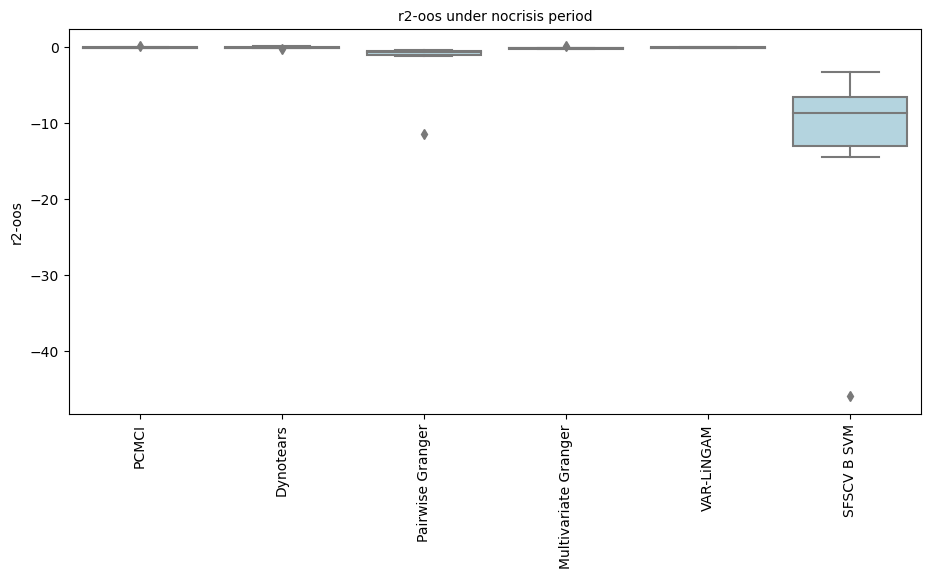

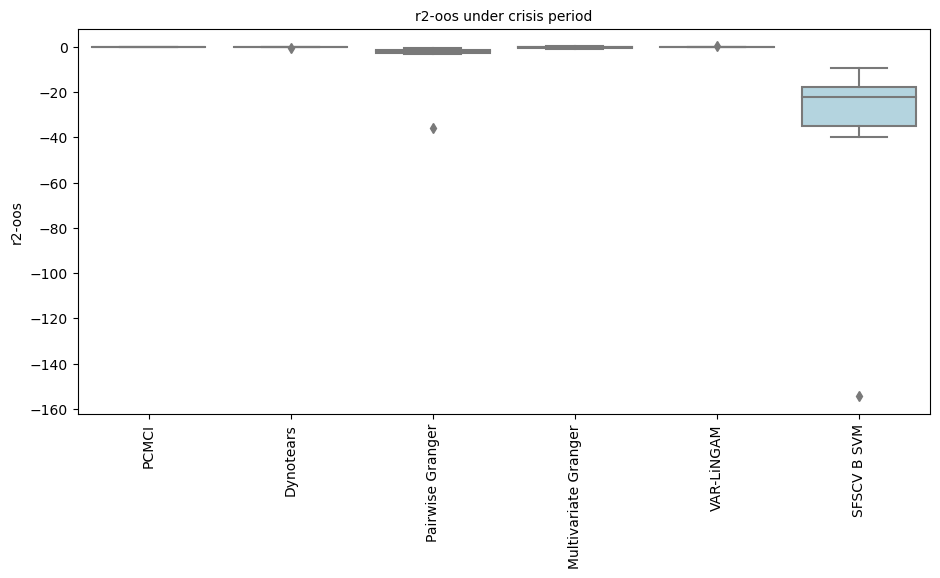

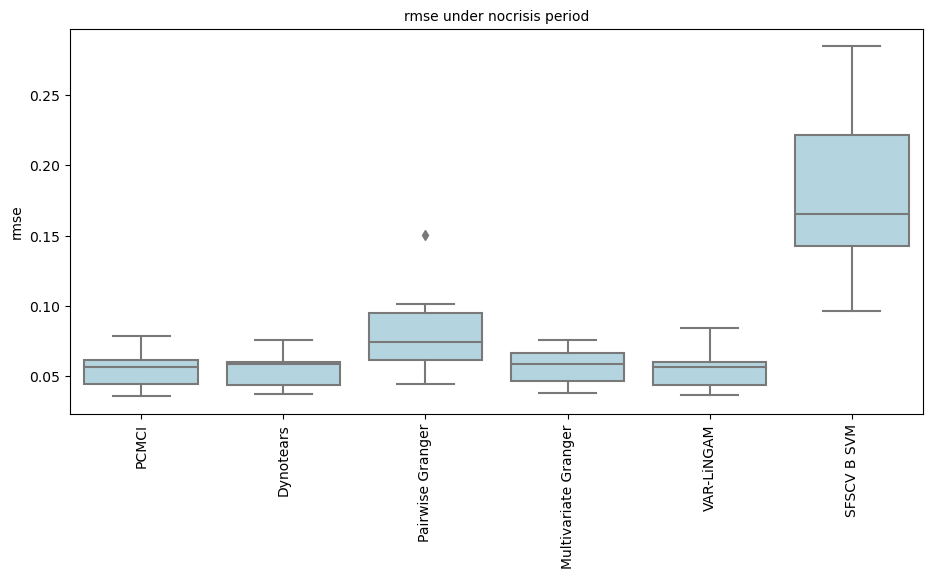

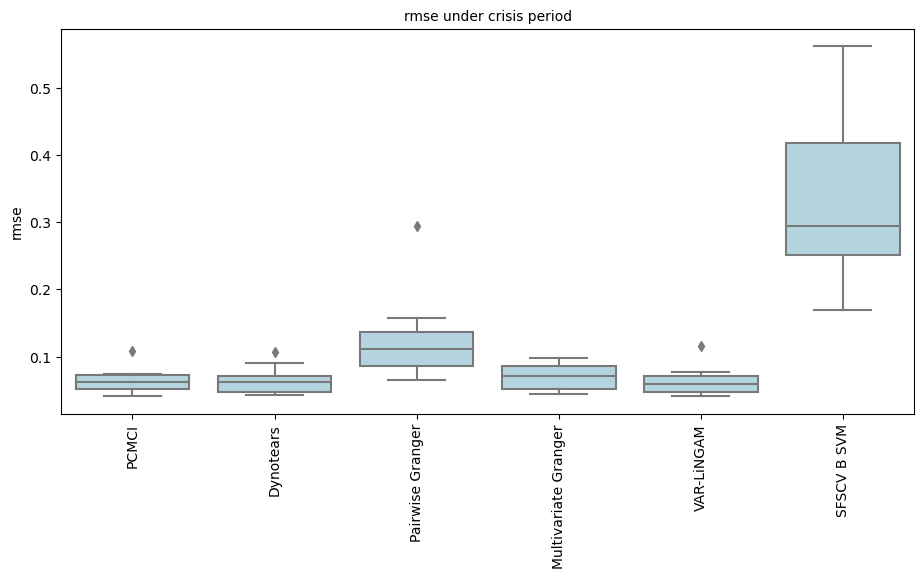

In [21]:
for m in metric_names:
    for c in melted_all_metrics_df["crisis"].unique():
        boxplot_df = melted_all_metrics_df.loc[(melted_all_metrics_df["variable"] == m)&
                                               (melted_all_metrics_df["crisis"] == c)].drop(["variable"], axis=1)

        fig, ax = plt.subplots(figsize=(11, 5))
        sns.boxplot(x="fs", y='value',data=boxplot_df, ax=ax, color='lightblue')
        ax.set_title(f"{m} under {c} period", fontsize=10)
        ax.set_ylabel(m, fontsize=10)
        ax.set_xlabel("", fontsize=10)
        ax.tick_params(axis="x", labelsize=10)
        ax.tick_params(axis="y", labelsize=10)
        # ax.legend(loc="best",fontsize=10)
        plt.xticks(rotation=90)
        fig.savefig(os.path.join(results_path, f'boxplot_agg_{m}_{c}_fs.png'))

## Prediction error over time

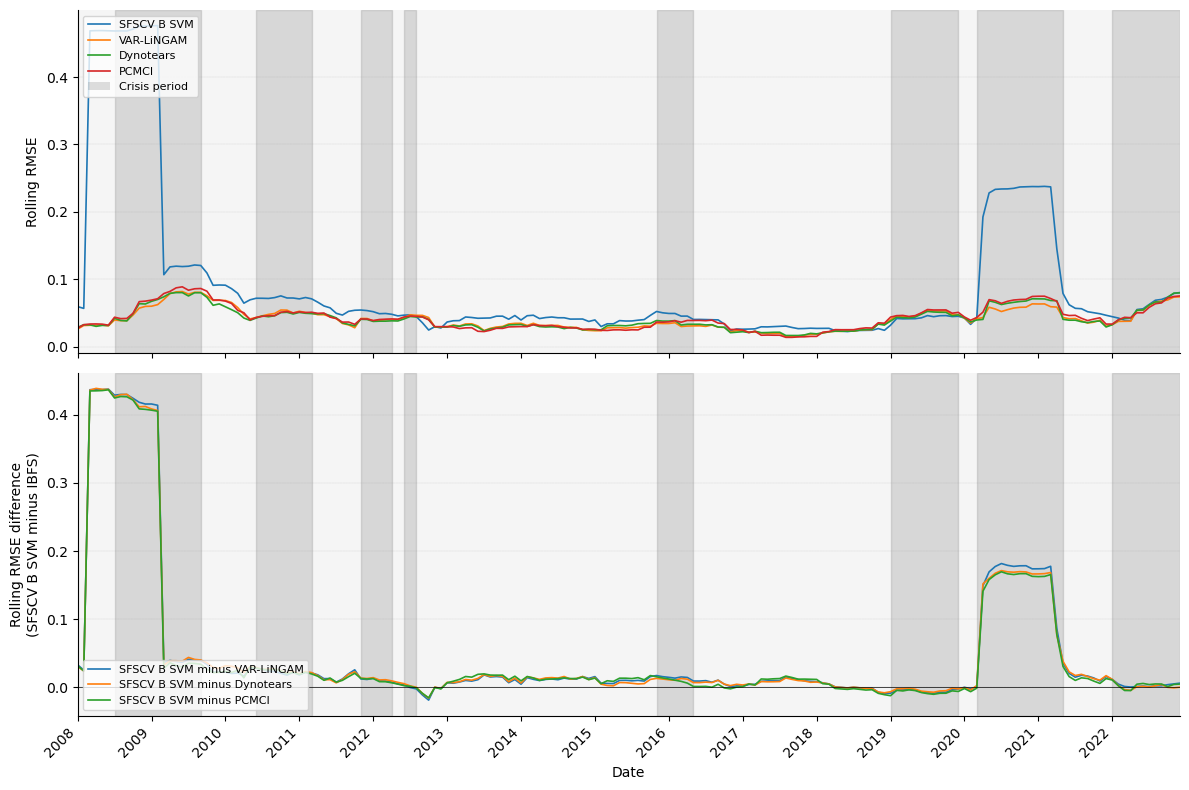

In [31]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

benchmarks = ["SFSCV B SVM", "SFSCV F Lin"]
causal_models = ["VAR-LiNGAM", "Dynotears", "PCMCI", "SeqICP"]
rolling_metric_name = "rolling_rmse"

for etf in all_rolling_metrics_df["etf"].unique():
    # Get rolling metrics for this ETF
    etf_rolling_metrics_df = all_rolling_metrics_df.loc[
        (all_rolling_metrics_df["etf"] == etf) & 
        (all_rolling_metrics_df["variable"] == rolling_metric_name)
    ].pivot_table(index=["date"], columns=["fs"], values=["value"])
    etf_rolling_metrics_df.columns = etf_rolling_metrics_df.columns.droplevel()

    # Compute volatility based crisis classification using true returns
    fs_methods = all_fs_methods[etf]
    dataset_name = dataset_names[etf]
    first_fs = fs_methods[0]
    files = glob.glob(os.path.join(outputs_path, first_fs, dataset_name, f"{etf}*.pickle"))
    dfPred = load_pickle(files[0])["predictions"].loc["2006-01-01":]
    true_returns = dfPred["true"]
    
    # Compute rolling volatility from true returns
    volatility = true_returns.rolling(6).std() * np.sqrt(12)
    threshold = volatility.mean()
    
    vol_aligned = volatility.reindex(etf_rolling_metrics_df.index)
    crisis_mask = vol_aligned >= threshold

    # Identify crisis blocks
    crisis_blocks = []
    in_crisis = False
    start = None
    for date, is_crisis in crisis_mask.items():
        if is_crisis and not in_crisis:
            start = date
            in_crisis = True
        elif not is_crisis and in_crisis:
            crisis_blocks.append((start, date))
            in_crisis = False
    if in_crisis:
        crisis_blocks.append((start, crisis_mask.index[-1]))

    # One full plot per benchmark
    for i, benchmark_name in enumerate(benchmarks):
        if benchmark_name not in etf_rolling_metrics_df.columns:
            continue

        # Build plot dataframe
        plot_models = [benchmark_name] + [m for m in causal_models if m in etf_rolling_metrics_df.columns]
        plot_df = etf_rolling_metrics_df[plot_models].copy()

        # Compute differences
        diff_cols = []
        for causal_name in causal_models:
            if causal_name not in etf_rolling_metrics_df.columns:
                continue
            col = f"{benchmark_name} minus {causal_name}"
            plot_df[col] = plot_df[benchmark_name] - plot_df[causal_name]
            diff_cols.append(col)

        # Plotting
        fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        # Upper subplot: rolling RMSE levels
        plot_df[plot_models].plot(ax=axs[0], linewidth=1.2)
        axs[0].set_ylabel('Rolling RMSE')
        axs[0].grid(True, axis='y', which='major', linestyle='--', 
                     linewidth='0.1', color='gray')
        axs[0].set_facecolor('whitesmoke')
        axs[0].spines['top'].set_visible(False)
        axs[0].spines['right'].set_visible(False)

        # Lower subplot: RMSE differences
        plot_df[diff_cols].plot(ax=axs[1], linewidth=1.2)
        axs[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        axs[1].set_xlabel('Date')
        axs[1].set_ylabel(f'Rolling RMSE difference\n({benchmark_name} minus IBFS)')
        axs[1].grid(True, axis='y', which='major', linestyle='--', 
                     linewidth='0.1', color='gray')
        axs[1].set_facecolor('whitesmoke')
        axs[1].spines['top'].set_visible(False)
        axs[1].spines['right'].set_visible(False)

        # Add crisis shading
        for start_date, end_date in crisis_blocks:
            axs[0].axvspan(pd.to_datetime(start_date), pd.to_datetime(end_date), 
                           color='grey', alpha=0.25, label='_nolegend_')
            axs[1].axvspan(pd.to_datetime(start_date), pd.to_datetime(end_date), 
                           color='grey', alpha=0.25, label='_nolegend_')

        # Add crisis patch to upper legend
        crisis_patch = Patch(facecolor='grey', alpha=0.25, label='Crisis period')
        handles_upper = axs[0].get_legend_handles_labels()[0] + [crisis_patch]
        axs[0].legend(handles=handles_upper, loc='upper left', fontsize=8)
        axs[1].legend(loc='lower left' if i ==0 else 'upper left', fontsize=8)

        # Set x-ticks
        tick_positions = pd.date_range(
            start=plot_df.index.min(), 
            end=plot_df.index.max(), 
            freq='AS'
        )
        axs[1].set_xticks(tick_positions)
        axs[1].set_xticklabels([tp.strftime('%Y') for tp in tick_positions], 
                               rotation=45, ha='right')

        # axs[0].set_title(f'{etf} — Benchmark: {benchmark_name}')

        plt.tight_layout()
        fig.savefig(os.path.join(results_path, 
                    f'{etf}_rolling_rmse_vs_{benchmark_name.replace(" ", "_")}.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()

In [17]:
results_path

'/home/danielco/Downloads/cml-fin/src/data/outputs/results'

## Features Heatmap

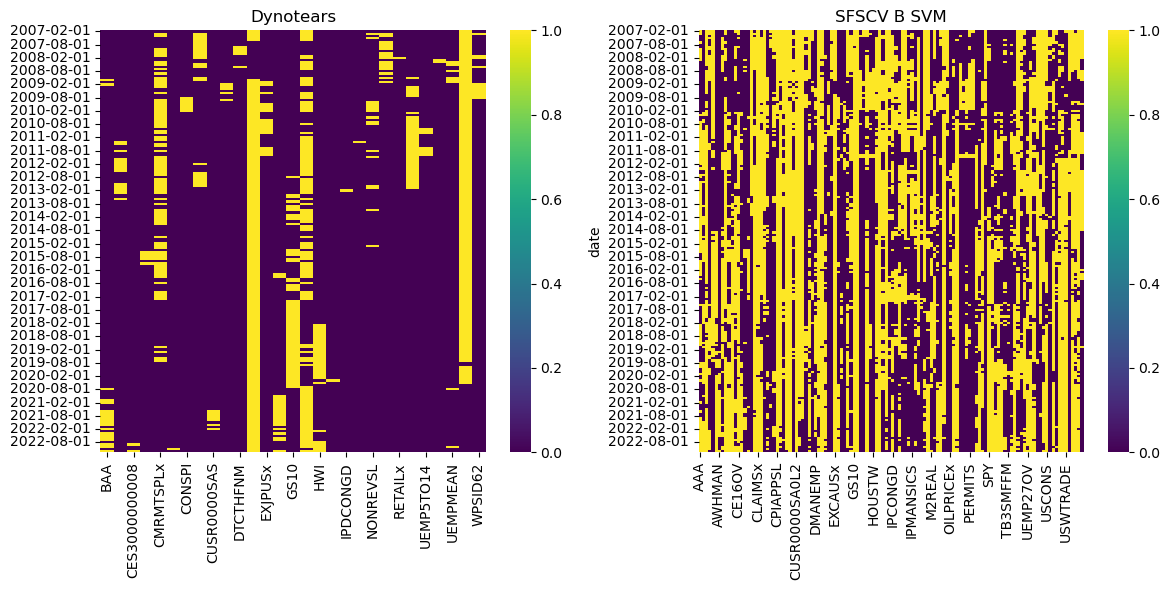

In [33]:
etf = "SPY"
first_fs = "dynotears_nocluster"
second_fs = "sfscv-backward-svm_nocluster"

# Create a figure with 2 subplots (side by side)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# First heatmap
check_df = all_parents_df.loc[(all_parents_df['etf'] == etf) & (all_parents_df['fs'] == first_fs)].drop(["etf", "fs"], axis=1)
check_df["date"] = [pd.to_datetime(dtref).strftime('%Y-%m-%d') for dtref in check_df["date"]]
pivot_table_data = check_df.pivot_table(index=["date"], columns=["fred"], values=["value"]).fillna(0)

# # Resample
# pivot_table_data.index = pd.to_datetime(pivot_table_data.index)
# pivot_table_data = pivot_table_data.resample("M").last().fillna(0)

# Fix date index
pivot_table_data.index = [pd.to_datetime(dtref).strftime('%Y-%m-%d') for dtref in pivot_table_data.index]

pivot_table_data.columns = pivot_table_data.columns.droplevel()
pivot_table_data.columns.name = ""

sns.heatmap(pivot_table_data, ax=axs[0], cmap="viridis")
axs[0].set_title(fs_methods_tags[first_fs])
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=90)  # Rotate column names

selected_dates = pivot_table_data.index

# Second heatmap
check_df = all_parents_df.loc[(all_parents_df['etf'] == etf) & (all_parents_df['fs'] == second_fs)].drop(["etf", "fs"], axis=1)
check_df["date"] = [pd.to_datetime(dtref).strftime('%Y-%m-%d') for dtref in check_df["date"]]
pivot_table_data = check_df.pivot_table(index=["date"], columns=["fred"], values=["value"]).fillna(0)

pivot_table_data.columns = pivot_table_data.columns.droplevel()
pivot_table_data.columns.name = ""

pivot_table_data = pivot_table_data[(pd.to_datetime(selected_dates[0]) - relativedelta(months=0)).strftime("%Y-%m-%d"):]

sns.heatmap(pivot_table_data, ax=axs[1], cmap="viridis")
axs[1].set_title(fs_methods_tags[second_fs])
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=90)  # Rotate column names

# Adjust layout
plt.tight_layout()

# Save plot
fig.savefig(os.path.join(results_path, f'{etf}_{fs_methods_tags[first_fs]}_compare_clusters_heatmap.png'))

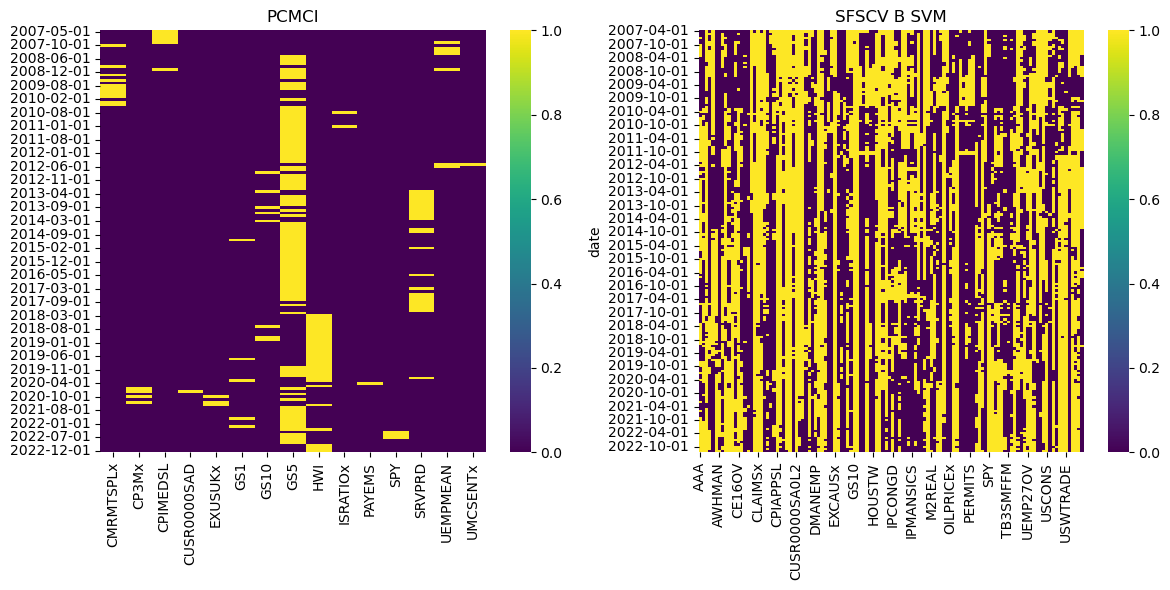

In [34]:
etf = "SPY"
first_fs = "pcmci_nocluster"
second_fs = "sfscv-backward-svm_nocluster"


# Create a figure with 2 subplots (side by side)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# First heatmap
check_df = all_parents_df.loc[(all_parents_df['etf'] == etf) & (all_parents_df['fs'] == first_fs)].drop(["etf", "fs"], axis=1)
check_df["date"] = [pd.to_datetime(dtref).strftime('%Y-%m-%d') for dtref in check_df["date"]]
pivot_table_data = check_df.pivot_table(index=["date"], columns=["fred"], values=["value"]).fillna(0)

# # Resample
# pivot_table_data.index = pd.to_datetime(pivot_table_data.index)
# pivot_table_data = pivot_table_data.resample("M").last().fillna(0)

# Fix date index
pivot_table_data.index = [pd.to_datetime(dtref).strftime('%Y-%m-%d') for dtref in pivot_table_data.index]

pivot_table_data.columns = pivot_table_data.columns.droplevel()
pivot_table_data.columns.name = ""

sns.heatmap(pivot_table_data, ax=axs[0], cmap="viridis")
axs[0].set_title(fs_methods_tags[first_fs])
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=90)  # Rotate column names

selected_dates = pivot_table_data.index

# Second heatmap
check_df = all_parents_df.loc[(all_parents_df['etf'] == etf) & (all_parents_df['fs'] == second_fs)].drop(["etf", "fs"], axis=1)
check_df["date"] = [pd.to_datetime(dtref).strftime('%Y-%m-%d') for dtref in check_df["date"]]
pivot_table_data = check_df.pivot_table(index=["date"], columns=["fred"], values=["value"]).fillna(0)

# # Resample
# pivot_table_data.index = pd.to_datetime(pivot_table_data.index)
# pivot_table_data = pivot_table_data.resample("M").last().fillna(0)

pivot_table_data.columns = pivot_table_data.columns.droplevel()
pivot_table_data.columns.name = ""

pivot_table_data = pivot_table_data[(pd.to_datetime(selected_dates[0]) - relativedelta(months=1)).strftime("%Y-%m-%d"):]

sns.heatmap(pivot_table_data, ax=axs[1], cmap="viridis")
axs[1].set_title(fs_methods_tags[second_fs])
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=90)  # Rotate column names

# Adjust layout
plt.tight_layout()

# Save plot
fig.savefig(os.path.join(results_path, f'{etf}_{fs_methods_tags[first_fs]}_compare_clusters_heatmap.png'))

## Selected Features During Specific Periods

In [35]:
dict(event_dates)

{'GFC': ('2007-07-01', '2008-11-01'),
 'Dow Jones Flash Crash': ('2010-03-01', '2010-07-01'),
 'Tsunami Fukushima': ('2011-01-01', '2011-05-01'),
 'Black Monday 2011': ('2011-06-01', '2011-10-01'),
 'Chinese Black Monday': ('2015-06-01', '2015-10-01'),
 'Dow Jones Plunge 2018': ('2018-01-01', '2018-05-01'),
 'COVID-19': ('2020-01-01', '2020-05-01')}

In [36]:
event_dates_dict = dict(event_dates)
etf = "SPY" # "ldEXME"
fs = "dynotears_nocluster"
for crisis_name in event_dates_dict.keys():

    check_df = all_parents_df.loc[(all_parents_df['etf'] == etf)&(all_parents_df['fs'] == fs)].drop(["etf", "fs"], axis=1)
    check_df = check_df.set_index("date")

    check_df = check_df.loc[:event_dates_dict[crisis_name][0]]
    check_df = check_df.reset_index()

print(check_df.pivot_table(index=["date"], columns=["fred"], values=["value"]).dropna(axis=1, how="all").iloc[-1].dropna())

       fred    
value  EXCAUSx     1.0
       GS10        1.0
       HWI         1.0
       UMCSENTx    1.0
Name: 2020-01-01 00:00:00, dtype: float64


## Stability Measure

In [37]:
all_etfs_scores = []
all_avg_scores = []
for ticker in all_parents_df["etf"].unique():
    etf_df = all_parents_df[(all_parents_df["etf"] == ticker)]
    etf_df.loc[:, "date"] = [dtref.strftime("%Y-%m-%d") for dtref in etf_df["date"]]

    etf_df = etf_df.sort_values(by=["date"])
    all_scores = []
    for fs in etf_df["fs"].unique():
        fs_etf_df = etf_df[etf_df["fs"] == fs]

        score = []
        for i, date in enumerate(fs_etf_df["date"].unique()):
            if i == 0:
                F_tm1 = set(fs_etf_df.loc[fs_etf_df["date"] == date]["cluster"].dropna().values)
                s = 0
            else:
                F_t = set(fs_etf_df.loc[fs_etf_df["date"] == date]["cluster"].dropna().values)
                s = len(F_tm1.intersection(F_t)) / len(F_tm1.union(F_t)) if len(F_tm1.union(F_t)) != 0 else np.nan
                F_tm1 = copy(F_t)
            score.append({"date": date, "score": s})
        score_df = pd.DataFrame(score)
        score_df["fs"] = fs_methods_tags[fs]

        melt_score_df = score_df.melt(["date", "fs"])
        all_scores.append(melt_score_df)
    all_scores_df = pd.concat(all_scores).drop("variable", axis=1)
    all_scores_df["etf"] = ticker
    all_etfs_scores.append(all_scores_df)

    avg_scores = all_scores_df.groupby(["fs"])[["value"]].mean().sort_values(by=["value"], ascending=False).reset_index()
    avg_scores['ticker'] = ticker
    avg_scores = avg_scores[['ticker', 'fs', 'value']]
    all_avg_scores.append(avg_scores)
all_avg_scores_df = pd.concat(all_avg_scores)
all_etfs_scores_df = pd.concat(all_etfs_scores)

In [38]:
all_etfs_scores_df.groupby("fs").mean()[["value"]].round(3).sort_values('value', ascending=False)

,value
fs,
Pairwise Granger,0.927
Dynotears,0.813
Multivariate Granger,0.804
SFSCV B SVM,0.785
PCMCI,0.664
VAR-LiNGAM,0.640


<Axes: xlabel='date'>

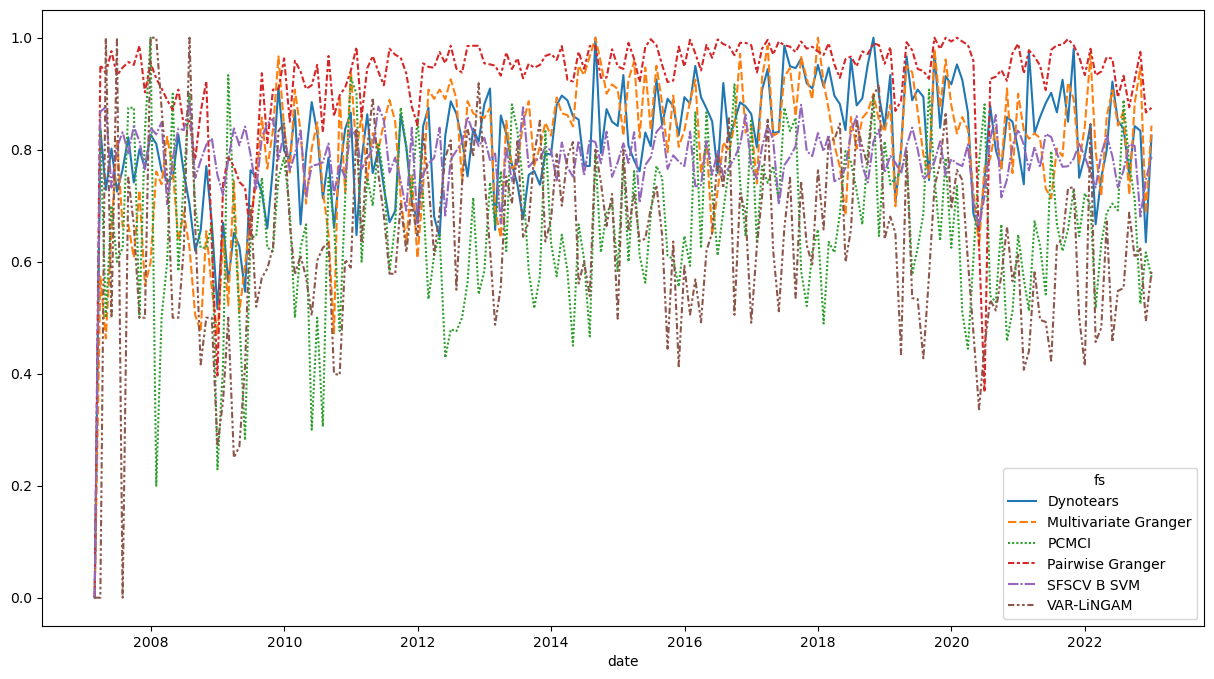

In [39]:
pivot_all_etfs_scores_df = all_etfs_scores_df.pivot_table(index=["date"], columns=["fs"], values=["value"])
pivot_all_etfs_scores_df.columns = pivot_all_etfs_scores_df.columns.droplevel(0)
pivot_all_etfs_scores_df.index = pd.to_datetime(pivot_all_etfs_scores_df.index)
pivot_all_etfs_scores_df = pivot_all_etfs_scores_df.resample("M").last().fillna(0)

plt.figure(figsize=(15, 8))
sns.lineplot(data=pivot_all_etfs_scores_df)